In [ ]:
#Generates the Monte Carlo stress scenarios from the pre-COVID GJR-GARCH parameters: 10,000 paths × 252 days for the six scenarios.
#Produces Table 2 and the representative paths in Figure 5. Section 3.5.

In [20]:
 
import json
import os
import numpy as np
 
# ---- config -------------------------------------------------------------
N_PATHS   = 10000
N_DAYS    = 252
OUT_DIR   = "../data/simulated"          # where the LSTM loads mc_returns_*.npy
PARAMS_JSON = "../results/garch_params.json"
MASTER_SEED = 42
 
# squeeze parameters (match these to your thesis text)
SQUEEZE_ONSET = 200
SQUEEZE_MMAX  = 5.0

SQUEEZE_TAU   = 10.0
 
# structural break parameters
BREAK_DAY        = 180
BREAK_MULTIPLIER = 3.0     # omega jumps 1.0x -> 3.0x at BREAK_DAY
 
os.makedirs(OUT_DIR, exist_ok=True)

In [21]:
with open(PARAMS_JSON) as f:
    params = json.load(f)
 
base = params["pre_covid"]
OMEGA = base["omega"]     
ALPHA = base["alpha"]
GAMMA = base["gamma"]
BETA  = base["beta"]
print(f"baseline (pre-covid): omega={OMEGA:.6f} alpha={ALPHA:.4f} "
      f"gamma={GAMMA:.4f} beta={BETA:.4f}")
 

baseline (pre-covid): omega=0.035730 alpha=0.0000 gamma=0.2793 beta=0.8161


In [22]:
def simulate(rng, omega_schedule, sigma_multiplier=None):
    """
    Simulate N_PATHS x N_DAYS GJR-GARCH(1,1) returns on the percent scale.

    Model
    -----
    Each path follows the GJR-GARCH(1,1) recursion, with the return treated as a
    zero-mean shock r_t = sigma_t * z_t, z_t ~ N(0, 1):

        sigma^2_t = omega_t + alpha * r_{t-1}^2
                            + gamma * I_{t-1} * r_{t-1}^2
                            + beta  * sigma^2_{t-1},

    where I_{t-1} = 1 if r_{t-1} < 0 and 0 otherwise (the leverage term, so
    negative shocks raise future variance more than positive ones).

    Initialisation
    --------------
    Each path starts at the regime's long-run (unconditional) variance so it
    begins at equilibrium rather than an arbitrary value:

        sigma^2_0 = omega_0 / (1 - (alpha + beta + gamma/2)).

    Because sigma^2_0 uses omega_0, a scenario that scales omega by k also scales
    the whole variance level by k (and the volatility by sqrt(k)), while the
    dynamics alpha, gamma, beta stay fixed.

    Parameters
    ----------
    rng : np.random.Generator
        Seeded generator, so each scenario is reproducible.
    omega_schedule : array, length N_DAYS
        The omega used on each day. Constant for the magnitude-scaling scenarios;
        stepped up at BREAK_DAY for the Structural Break (a level change only).
    sigma_multiplier : array, length N_DAYS, optional
        A deterministic per-day multiplier M(t) applied to the OUTPUT returns
        (used by the Non-linear Squeeze). None means no overlay.

    The squeeze overlay (and why it is output-only)
    -----------------------------------------------
    When sigma_multiplier is given, the finished returns are scaled day by day:

        r_final_t = M(t) * r_clean_t   =>   sigma_final_t = M(t) * sigma_t,

    so at the peak M(t) = M_max = 5 the volatility is exactly 5x the baseline,
    bounded and predictable. The multiplier is applied ONLY to the output, never
    fed back into the variance recursion. If it were fed back, the inflated shock
    (M(t) * r_t) would enter the ARCH/GJR terms squared, multiplying next day's
    variance by M(t)^2; that amplification would then compound day after day
    (M, M^2, M^3, ...) and the paths would explode to overflow/NaN. Keeping the
    recursion on the clean process and overlaying M(t) afterwards avoids this
    feedback loop.

    Worked example (pre-COVID: omega=0.0357, alpha=0, beta=0.8161, gamma=0.2793)
    ---------------------------------------------------------------------------
    sigma^2_0 = 0.0357 / (1 - 0.9558) = 0.807, so sigma_0 = 0.90%.
      Day 0, z=+0.5:  r0 = 0.90 * 0.5 = +0.45%   (positive -> no leverage)
      Day 1:          sigma^2_1 = 0.0357 + 0.8161*0.807 = 0.695, sigma_1 = 0.83%
                      z=-2.0:  r1 = 0.83 * (-2.0) = -1.67%   (negative -> leverage on)
      Day 2:          sigma^2_2 = 0.0357 + 0.2793*(1.67^2) + 0.8161*0.695 = 1.379,
                      sigma_2 = 1.17%   (volatility spikes after the down day)

    Returns
    -------
    np.ndarray, shape (N_PATHS, N_DAYS)
        Simulated percent-scale returns for the scenario.
    """
    ret_clean = np.zeros((N_PATHS, N_DAYS))   # drives the recursion
    s2  = np.zeros((N_PATHS, N_DAYS))
    z   = rng.standard_normal((N_PATHS, N_DAYS))
    denom = max(1 - ALPHA - BETA - GAMMA / 2, 0.02)
    s2[:, 0] = omega_schedule[0] / denom # This part initialises each path at the scenario's long-run variance ω/(1−persistence)
    ret_clean[:, 0] = np.sqrt(s2[:, 0]) * z[:, 0] # today's volatility × a random draw

    #GJR- recursion loop 
    for t in range(1, N_DAYS):
        neg = (ret_clean[:, t-1] < 0).astype(float)
        s2[:, t] = (omega_schedule[t]
                    + ALPHA * ret_clean[:, t-1]**2
                    + GAMMA * neg * ret_clean[:, t-1]**2
                    + BETA * s2[:, t-1])
        s2[:, t] = np.maximum(s2[:, t], 1e-12)
        ret_clean[:, t] = np.sqrt(s2[:, t]) * z[:, t]
 
    if sigma_multiplier is None:
        return ret_clean
    # overlay the squeeze on the finished paths (row-wise * per-day multiplier)
    return ret_clean * sigma_multiplier[np.newaxis, :]

In [23]:

""" Building the six stress scenarios

This cell generates the six Monte Carlo scenarios of Table 2, each 10,000 paths
of 252 days, all from the same pre-COVID GJR-GARCH engine.

**Reproducibility.** `SeedSequence(MASTER_SEED).spawn(6)` creates six independent,
reproducible random streams, one per scenario, so no two scenarios share draws
and every run is identical.

**(a) Magnitude-scaling scenarios.** Only the baseline variance ω is scaled by a
constant k, holding the dynamics (α, γ, β) fixed. By the corollary in
Appendix A.1, scaling ω by k scales the long-run variance by k and the long-run
volatility by √k:
- Normal (k = 1.0) → ≈ 0.90%/day
- COVID crisis magnitude (k = 1.8) → ≈ 1.21%/day
- 2008 crisis magnitude (k = 2.5) → ≈ 1.42%/day
- Synthetic Extreme (k = 3.0) → ≈ 1.56%/day

**(b) Structural Break.** ω is held at the baseline until day 180, then stepped up
to 3× for the rest of the path. This is a mid-path change in the variance *level*
only; the dynamics α, γ, β are unchanged, so it is not a true change of regime
despite the name.

**(c) Non-linear Squeeze.** A deterministic multiplier grows smoothly after day
200 following M(t) = 1 + (M_max − 1)(1 − e^{−(t − t*)/τ}), with M_max = 5, t* = 200,
τ = 10. It is applied as an overlay to the output volatility (σ_final,t = M(t)·σt),
not fed back into the recursion, so at the peak volatility reaches 5 × baseline
≈ 4.5%/day without exploding.

"""


# Six independent, reproducible random streams (one per scenario)
seeds = {name: np.random.default_rng(np.random.SeedSequence(MASTER_SEED).spawn(6)[i])
         for i, name in enumerate(
             ["normal", "crisis_covid", "crisis_2008", "synthetic_extreme",
              "structural_break", "squeeze"])}
 
scenarios = {}


# (a) Magnitude-scaling scenarios: constant omega * k (dynamics unchanged).
#     Scaling omega by k scales long-run volatility by sqrt(k).
for name, mult in [("normal", 1.0), ("crisis_covid", 1.8),
                   ("crisis_2008", 2.5), ("synthetic_extreme", 3.0)]:
    sched = np.full(N_DAYS, OMEGA * mult)
    scenarios[name] = simulate(seeds[name], sched)

    
 
# (b) Structural Break: omega steps 1.0x -> 3.0x at BREAK_DAY.
#     A mid-path LEVEL change only; the dynamics (alpha, gamma, beta) are
#     unchanged, so this is not an entirely structural regime switch.
sched = np.full(N_DAYS, OMEGA * 1.0)
sched[BREAK_DAY:] = OMEGA * BREAK_MULTIPLIER
scenarios["structural_break"] = simulate(seeds["structural_break"], sched)



# (c) Non-linear Squeeze: exponential multiplier M(t) applied to sigma from
#     SQUEEZE_ONSET, as a deterministic overlay on the output (not fed back).
t = np.arange(N_DAYS)
M = np.ones(N_DAYS)
after = t >= SQUEEZE_ONSET
M[after] = 1 + (SQUEEZE_MMAX - 1) * (1 - np.exp(-(t[after] - SQUEEZE_ONSET) / SQUEEZE_TAU))
sched = np.full(N_DAYS, OMEGA)
scenarios["squeeze"] = simulate(seeds["squeeze"], sched, sigma_multiplier=M)

In [24]:
'''### Saving and sanity-checking the scenarios

This cell writes each scenario to disk and runs three checks before the LSTM
notebook uses the paths.

1. **Finiteness guard.** `assert np.isfinite(paths).all()` fails loudly if any
   path contains NaN or inf. This is the safety net for the squeeze: if the
   multiplier had been fed back into the recursion it would explode, and this
   assert would catch it. All scenarios pass because the squeeze is an output
   overlay.
2. **Save.** Each scenario is saved as `mc_returns_<name>.npy` in `OUT_DIR`, the
   files the LSTM stress-test notebook loads.
3. **Report + distinctness checks.** Prints each scenario's standard deviation and
   largest absolute return, and confirms the Structural Break and Non-linear
   Squeeze are genuinely different arrays from the 2008-magnitude scenario (not
   accidentally duplicated).

The Normal scenario's standard deviation is the key diagnostic: from the pre-COVID
long-run volatility it should be about 0.90%/day.

'''

for name, paths in scenarios.items():
    assert np.isfinite(paths).all(), f"{name}: non-finite values"
    np.save(os.path.join(OUT_DIR, f"mc_returns_{name}.npy"), paths)
 
 
# ---- 5. report ----------------------------------------------------------
print("\nscenario           std     |r| max   saved as")
print("-" * 60)
for name, paths in scenarios.items():
    print(f"{name:18}{paths.std():6.3f}{np.abs(paths).max():9.2f}   "
          f"mc_returns_{name}.npy")
 
# confirm the two special scenarios are genuinely different from crisis_2008
d1 = not np.allclose(scenarios["structural_break"], scenarios["crisis_2008"])
d2 = not np.allclose(scenarios["squeeze"], scenarios["crisis_2008"])


# normal std should be ~0.90 (pre-COVID long-run volatility, omega/(1-persistence)).
# Any shortfall vs the real 2010-2019 return std is the sim-to-real gap (Sec 4.2/5.1).
print(f"\nstructural_break distinct from crisis_2008? {d1}")
print(f"squeeze distinct from crisis_2008?          {d2}")
print(f"\nnormal std = {scenarios['normal'].std():.3f}  "
      f"(should be ~0.90 to match percent-scale training returns)")


scenario           std     |r| max   saved as
------------------------------------------------------------
normal             0.903    80.23   mc_returns_normal.npy
crisis_covid       1.212    84.70   mc_returns_crisis_covid.npy
crisis_2008        1.414    49.51   mc_returns_crisis_2008.npy
synthetic_extreme  1.543    59.37   mc_returns_synthetic_extreme.npy
structural_break   1.070    34.76   mc_returns_structural_break.npy
squeeze            1.932   107.70   mc_returns_squeeze.npy

structural_break distinct from crisis_2008? True
squeeze distinct from crisis_2008?          True

normal std = 0.903  (should be ~0.90 to match percent-scale training returns)


In [25]:
# Define your scenarios with shock multipliers
scenarios = {
    'normal': {
        'shock_multiplier': 1.0,
        'color': 'blue',
        'description': 'Normal market conditions'
    },
    'crisis_2008': {
        'shock_multiplier': 2.5,
        'color': 'red',
        'description': '2008-style financial crisis'
    },
    'crisis_covid': {
        'shock_multiplier': 1.8,
        'color': 'orange',
        'description': 'COVID-19 pandemic crisis'
    },
    'synthetic_extreme': {
        'shock_multiplier': 3.0,
        'color': 'purple',
        'description': 'Synthetic extreme crisis (beyond historical)'
    }
}

print("Scenarios defined:")
for name, config in scenarios.items():
    print(f"  {name}: {config['shock_multiplier']}x → {config['description']}")

Scenarios defined:
  normal: 1.0x → Normal market conditions
  crisis_2008: 2.5x → 2008-style financial crisis
  crisis_covid: 1.8x → COVID-19 pandemic crisis
  synthetic_extreme: 3.0x → Synthetic extreme crisis (beyond historical)


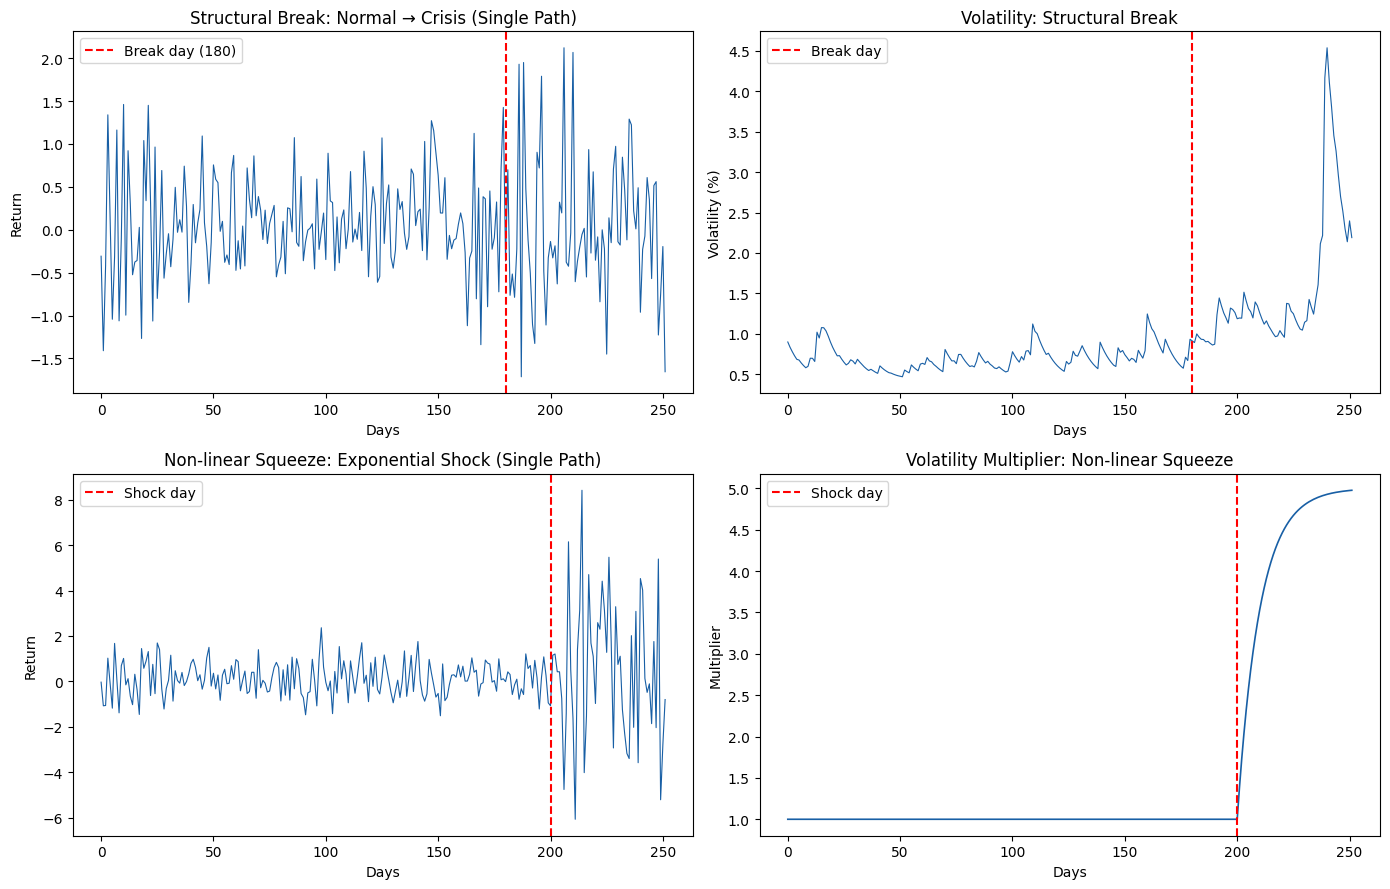

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ---- parameters: must match your generator ----
OMEGA, ALPHA, GAMMA, BETA = 0.035730, 0.0000, 0.2793, 0.8161   # pre-COVID baseline
N_DAYS = 252
BREAK_DAY, BREAK_MULTIPLIER = 180, 3.0
SQUEEZE_ONSET, SQUEEZE_MMAX, SQUEEZE_TAU = 200, 5.0, 10.0
OUT_DIR = "../data/simulated"
PATH_IDX = 0   # which of the 10,000 paths to show as the representative example

# ---- load the saved paths (returns only) ----
break_ret = np.load(os.path.join(OUT_DIR, "mc_returns_structural_break.npy"))[PATH_IDX]
sq_ret    = np.load(os.path.join(OUT_DIR, "mc_returns_squeeze.npy"))[PATH_IDX]

# ---- recompute ONE structural-break volatility path (not saved in the .npy) ----
def one_vol_path(omega_schedule, seed=0):
    rng = np.random.default_rng(seed)
    ret = np.zeros(N_DAYS); s2 = np.zeros(N_DAYS)
    z = rng.standard_normal(N_DAYS)
    denom = max(1 - ALPHA - BETA - GAMMA/2, 0.02)
    s2[0] = omega_schedule[0] / denom
    ret[0] = np.sqrt(s2[0]) * z[0]
    for t in range(1, N_DAYS):
        neg = 1.0 if ret[t-1] < 0 else 0.0
        s2[t] = omega_schedule[t] + ALPHA*ret[t-1]**2 + GAMMA*neg*ret[t-1]**2 + BETA*s2[t-1]
        s2[t] = max(s2[t], 1e-12)
        ret[t] = np.sqrt(s2[t]) * z[t]
    return np.sqrt(s2)     # conditional volatility

sched_break = np.full(N_DAYS, OMEGA); sched_break[BREAK_DAY:] = OMEGA * BREAK_MULTIPLIER
break_vol = one_vol_path(sched_break)

# ---- squeeze multiplier curve ----
t = np.arange(N_DAYS)
M = np.ones(N_DAYS)
after = t >= SQUEEZE_ONSET
M[after] = 1 + (SQUEEZE_MMAX - 1) * (1 - np.exp(-(t[after] - SQUEEZE_ONSET) / SQUEEZE_TAU))

# ---- plot ----
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0,0].plot(break_ret, color='#185FA5', linewidth=0.8)
axes[0,0].axvline(BREAK_DAY, color='red', linestyle='--', label=f'Break day ({BREAK_DAY})')
axes[0,0].set_title('Structural Break: Normal → Crisis (Single Path)')
axes[0,0].set_xlabel('Days'); axes[0,0].set_ylabel('Return'); axes[0,0].legend()

axes[0,1].plot(break_vol, color='#185FA5', linewidth=0.8)
axes[0,1].axvline(BREAK_DAY, color='red', linestyle='--', label='Break day')
axes[0,1].set_title('Volatility: Structural Break')
axes[0,1].set_xlabel('Days'); axes[0,1].set_ylabel('Volatility (%)'); axes[0,1].legend()

axes[1,0].plot(sq_ret, color='#185FA5', linewidth=0.8)
axes[1,0].axvline(SQUEEZE_ONSET, color='red', linestyle='--', label='Shock day')
axes[1,0].set_title('Non-linear Squeeze: Exponential Shock (Single Path)')
axes[1,0].set_xlabel('Days'); axes[1,0].set_ylabel('Return'); axes[1,0].legend()

axes[1,1].plot(M, color='#185FA5', linewidth=1.2)
axes[1,1].axvline(SQUEEZE_ONSET, color='red', linestyle='--', label='Shock day')
axes[1,1].set_title('Volatility Multiplier: Non-linear Squeeze')
axes[1,1].set_xlabel('Days'); axes[1,1].set_ylabel('Multiplier'); axes[1,1].legend()

plt.tight_layout()
plt.savefig('../results/figures/structural_break_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
from pathlib import Path
import numpy as np

# Create directory if it doesn't exist
Path('../data/simulated').mkdir(parents=True, exist_ok=True)

# Save each scenario
for name, data in Paths.items():
    np.save(f'../data/simulated/mc_returns_{name}.npy', data['returns'])
    np.save(f'../data/simulated/mc_volatility_{name}.npy', data['volatility'])
    print(f"Saved: mc_returns_{name}.npy and mc_volatility_{name}.npy")

print("\n" + "="*60)
print("ALL FILES SAVED")
print("="*60)
print("Location: ../data/simulated/")
for name in all_paths.keys():
    print(f"  - mc_returns_{name}.npy")
    print(f"  - mc_volatility_{name}.npy")

NameError: name 'Paths' is not defined

In [34]:
print("\n" + "="*70)
print("MONTE CARLO SIMULATION SUMMARY")
print("="*70)

summary_data = []

for name, data in all_paths.items():
    returns = data['returns']
    volatility = data['volatility']
    
    summary_data.append({
        'Scenario': name.upper(),
        'Multiplier': scenarios[name]['shock_multiplier'],
        'Mean Return %': returns.mean() * 100,
        'Std Return %': returns.std() * 100,
        'Mean Vol %': volatility.mean(),
        'Max Vol %': volatility.max(),
        'Min Vol %': volatility.min()
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

print("\n" + "="*70)
print("✅ Monte Carlo simulation complete!")
print("Next step: Feed these paths into your LSTM model")
print("="*70)


MONTE CARLO SIMULATION SUMMARY
         Scenario  Multiplier  Mean Return %  Std Return %  Mean Vol %   Max Vol %  Min Vol %
           NORMAL         1.0       0.086100    116.300230    1.356077 1130.017076   0.221459
      CRISIS_2008         2.5       0.071279    184.686633    3.422154 1292.802990   0.544885
     CRISIS_COVID         1.8      -0.102403    154.571163    2.406476  309.567400   0.395166
SYNTHETIC_EXTREME         3.0      -0.133497    200.980950    4.053184 1242.243581   0.658098

✅ Monte Carlo simulation complete!
Next step: Feed these paths into your LSTM model


In [8]:

def scenario_statistics(scenarios, multipliers=None):
    """
    Summarise each Monte Carlo scenario using PER-PATH statistics.

    The order matters: for each scenario we first compute a statistic for every
    individual path (e.g. that path's own volatility), and only then aggregate
    those values across the 10,000 paths. Pooling all paths into one big series
    and taking a single volatility would blend 10,000 separate simulated years
    together and distort the result, which is why the per-path approach is correct.

    Parameters
    ----------
    scenarios : dict[str, np.ndarray]
        name -> returns array of shape (n_paths, n_days), on the percent scale.
    multipliers : dict[str, float | str], optional
        name -> the omega multiplier k (or a text label for the special scenarios),
        shown in the table for reference.

    Returns
    -------
    pd.DataFrame  with one row per scenario.
    """
    rows = []
    for name, returns in scenarios.items():
        # returns has shape (n_paths, n_days); axis=1 reduces along the days,
        # giving one value per path.
        path_vols  = returns.std(axis=1)    # each path's own volatility
        path_means = returns.mean(axis=1)   # each path's mean daily return
        path_mins  = returns.min(axis=1)    # each path's worst single day
        path_maxs  = returns.max(axis=1)    # each path's best single day

        rows.append({
            "Scenario":            name.upper(),
            "Multiplier":          (multipliers or {}).get(name, ""),
            "Mean Vol (%)":        path_vols.mean(),
            "Median Vol (%)":      np.median(path_vols),
            "Std Vol (%)":         path_vols.std(),
            "95th Pctile Vol (%)": np.percentile(path_vols, 95),
            "99th Pctile Vol (%)": np.percentile(path_vols, 99),
            "Max Vol (%)":         path_vols.max(),
            "Min Vol (%)":         path_vols.min(),
            "Mean Return (%)":     path_means.mean(),
            "Max Return (%)":      path_maxs.max(),   # largest up-move across all paths
            "Min Return (%)":      path_mins.min(),   # largest down-move across all paths
        })

    return pd.DataFrame(rows)


# Multiplier labels (the two path-based scenarios get text, not a single k)
multipliers = {
    "normal": 1.0, "crisis_covid": 1.8, "crisis_2008": 2.5,
    "synthetic_extreme": 3.0, "structural_break": "1.0->3.0", "squeeze": "exp->5.0",
}

stats_df = scenario_statistics(scenarios, multipliers)

print("=" * 70)
print("SCENARIO STATISTICS (per-path, aggregated across all paths)")
print("=" * 70)
print(stats_df.to_string(index=False, float_format="{:,.2f}".format))

AttributeError: 'dict' object has no attribute 'std'